In [1]:
using LinearAlgebra
using DifferentialEquations
using Plots
using PyCall
using DelimitedFiles
using NonlinearEigenproblems
include("CRD_STA.jl")

DevelopingSpatialMode (generic function with 1 method)

In [ ]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval,eigvec
end

In [ ]:
py"""
        import numpy as np
        from scipy.integrate import solve_bvp
        import matplotlib.pyplot as plt
        import math
        from math import sqrt
        Re_s = 10000
        def oneDiskODE(z,y):
                # Y0 = H, Y1 = F,Y2 = F', Y3 = F'', Y4 = G, Y5 = G'
                dH = -2 * sqrt(Re_s) * y[1]
                dydz = np.zeros((6, len(z)))
                dydz = np.array([dH , y[2] , y[3] , Re_s * ( (1/sqrt(Re_s)) * ( y[3] * y[0] + y[2] * dH) - 2 * y[4] * y[5] + 2 * y[1] * y[2]) , y[5] , Re_s * ( (1/sqrt(Re_s)) * y[5] * y[0] + 2 * y[1] * y[4])])
                return dydz 

        def oneDiskBC(ya, yb):
                resa = np.array([ya[0],ya[1], ya[4] - 0])
                
                resb = np.array([yb[0],yb[1], yb[4] - 1])
                
                return np.concatenate((resa, resb))


        z = np.linspace(0, 1, 20000)
        y = np.zeros((6, len(z)))
        y_guess = np.zeros((6, z.size))
        y_guess[0] = 1
        y_guess[1] = 0
        y_guess[2] = 0
        y_guess[3] = 0
        y_guess[4] = 1
        y_guess[5] = 0
        solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,max_nodes=5000000)

        x_plot = np.linspace(0, 1, 20000)


        y1_plot = solution.sol(x_plot)[0]
        y2_plot = solution.sol(x_plot)[1]
        y3_plot = solution.sol(x_plot)[4]
        y4_plot = solution.sol(x_plot)[2]
        y5_plot = solution.sol(x_plot)[5]
"""
Re_s = py"Re_s"
w0 = py"y1_plot"
u0 = py"y2_plot"
v0 = py"y3_plot"
du0 = py"y4_plot"
dv0 = py"y5_plot"
x = py"x_plot"

In [ ]:
plot(x,v0.-1)

In [ ]:
N_cheb = 9
Ro = 1
Tw = 1
Mr = 0.1
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
be = 0.115
num = 1
omega = 0.0
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
R = 27.4
Ma = Mr/R
eigval1,eigvec1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.5,num)
eigval1

In [ ]:

function BaseFlow(Re_s)
    py"""
    import numpy as np
    from scipy.integrate import solve_bvp
    import matplotlib.pyplot as plt
    import math
    from math import sqrt
    Re_s = $Re_s
    def oneDiskODE(z,y):
            # Y0 = H, Y1 = F,Y2 = F', Y3 = F'', Y4 = G, Y5 = G'
            dH = -2 * sqrt(Re_s) * y[1]
            dydz = np.zeros((6, len(z)))
            dydz = np.array([dH , y[2] , y[3] , Re_s * ( (1/sqrt(Re_s)) * ( y[3] * y[0] + y[2] * dH) - 2 * y[4] * y[5] + 2 * y[1] * y[2]) , y[5] , Re_s * ( (1/sqrt(Re_s)) * y[5] * y[0] + 2 * y[1] * y[4])])
            return dydz 

    def oneDiskBC(ya, yb):
            resa = np.array([ya[0],ya[1], ya[4] - 0])
            
            resb = np.array([yb[0],yb[1], yb[4] - 1])
            
            return np.concatenate((resa, resb))


    z = np.linspace(0, 1, 20000)
    y = np.zeros((6, len(z)))
    y_guess = np.zeros((6, z.size))
    y_guess[0] = 1
    y_guess[1] = 0
    y_guess[2] = 0
    y_guess[3] = 0
    y_guess[4] = 1
    y_guess[5] = 0
    solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,max_nodes=5000000)

    x_plot = np.linspace(0, 1, 20000)


    y1_plot = solution.sol(x_plot)[0]
    y2_plot = solution.sol(x_plot)[1]
    y3_plot = solution.sol(x_plot)[4]
    y4_plot = solution.sol(x_plot)[2]
    y5_plot = solution.sol(x_plot)[5]
    """
    w0 = py"y1_plot"
    u0 = py"y2_plot"
    v0 = py"y3_plot"
    du0 = py"y4_plot"
    dv0 = py"y5_plot"
    x = py"x_plot"
    return u0,v0,w0,du0,dv0,x
end
function velocity(u0,v0,w0,du0,dv0,t,phi)
    U = u0
    V = v0
    W = w0
    dU = du0
    dV = dv0
    F_U = itp = BSplineKit.interpolate(t, U , BSplineOrder(4))
    F_dU = itp = BSplineKit.interpolate(t, dU , BSplineOrder(4))
    F_dV = itp = BSplineKit.interpolate(t, dV , BSplineOrder(4))
    F_W= itp = BSplineKit.interpolate(t, W , BSplineOrder(4))
    F_phi = BSplineKit.interpolate(t, phi , BSplineOrder(4))
    return U,dU,V,dV,W,F_U,F_dU,F_dV,F_W,F_phi
end
function Cheb(N)
    θ = range(0,length=N+1,stop=pi)
    x = reshape(-cos.(θ), N+1, 1)
    c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
    X = repeat(x, 1, N+1);
    dX = X - X';
    D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
    D = D - diagm(vec(sum(D, dims=2))); 
    D = 2 * D
    x = 0.5 * (x .+1) 
    D2 = D^2;
    return D,D2,x
end
function phi_var(u,del,N)
    phi = zeros(N)
    for i = 1 : N
        z = 0
        for j = 1 : i
            z = z + u[j,1]*del
        end
        phi[i] = z
    end
    return phi
end
function f_q(sigma,F_du,F_dv,F_u,F_phi,tspan,t)
    function ODE_f!(du,u,p,t)
        q = u[1]
        dq = u[2]
        du[1] = dq
        du[2] = 2*sigma*(F_du(t)^2+F_dv(t)^2+F_u(t)*u[1]-F_phi(t)*u[2])
    end
    function BC_f!(residual, u, p, t)
        residual[1] = u[begin][1]
        residual[2] = u[end][1]
    end     
    prob = DifferentialEquations.BVProblem(ODE_f!, BC_f!, [0.0, 0.0], tspan)
    sol = solve(prob, Shooting(Vern7()), dt=0.01)
    f = sol(t)
    function ODE_q!(du,u,p,t)
        q = u[1]
        dq = u[2]
        du[1] = dq
        du[2] = -2*sigma*F_phi(t)*u[2]
    end
    function BC_q!(residual, u, p, t)
        residual[1] = u[begin][1] - 1
        residual[2] = u[end][1]
    end     
    prob = DifferentialEquations.BVProblem(ODE_q!, BC_q!, [1,0], tspan)
    sol1 = solve(prob,MIRK4(), dt=0.01)
    q = sol1(t)
    f = f[1,:]
    q = q[1,:]
    return f,q
  end
    function T_var(Mx,f,q,Tw,gamma)
    T = 1 .- ( (gamma-1)/2 )*Mx^2 * f + (Tw - 1) * q
    return T
    end

In [51]:
N = 20000
tspan = (0,30)
t = range(0,30,N)
sigma = 0.72
Mr = 0.3
Tw = 1
gamma = 1.4
u0,v0,w0,du0,dv0,x = BaseFlow(10000)
PHI = CRD_BF.phi_var(u0,t.step.hi,N)
u0,du0,v0,dv0,w0,F_u,F_du,F_dv,F_w,F_phi = velocity(u0,v0,w0,du0,dv0,t,PHI)
D,D2,x = Cheb(N_cheb)
f,q = CRD_BF.f_q(sigma,F_du,F_dv,F_u,F_phi,tspan,t)
T = CRD_BF.T_var(Mr,f,q,Tw,gamma)


┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/b4Q81/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/b4Q81/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/b4Q81/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/b4Q81/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/b4Q81/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/b4Q81/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/b4Q81/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

20000-element Vector{Float64}:
 1.0
 1.0082810834088998
 1.0165356871986182
 1.0247639052704047
 1.032965831223298
 1.0411415583542776
 1.0492911796584343
 1.0574147878291178
 1.0655124752581773
 1.0735843340360887
 ⋮
 1.2620875808772873
 1.2303490949593092
 1.1983366292708992
 1.1660478615663128
 1.133480449460754
 1.100632030259826
 1.067500220782768
 1.0340826172026094
 1.0003767948535447

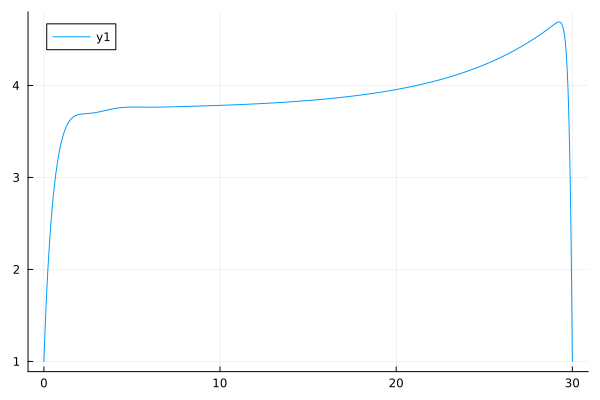

In [52]:
plot(t,T)